# HW 8 #

In [41]:
# Базовые библиотеки
import sys
import os 
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Датасеты / Трансформации
import torchvision
from torchvision import transforms

# Вспомогательные библиотеки
import json
import csv
from pathlib import Path
from io import BytesIO

#Воспроизводмость
SEED = 42
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

#Все пути
ARTIFACTS_PATH = Path("./artifacts")
FIGURES_PATH = ARTIFACTS_PATH / "figures"

DATA_PATH = Path("./data")


device: cuda


## Вспомогательные функции ##

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
def save_and_sync(filename: Path, content: bytes = None, use_drive: bool = True):
    """
    Сохраняет файл (текст или бинарный) и копирует на Google Drive.
    """
    # 1. Монтируем диск, если нужно
    if use_drive and 'google.colab' in sys.modules:
        try:
            drive.mount('/content/drive', force_remount=False)
            drive_path = Path(f"/content/drive/MyDrive/Colab_Projects/HW08-09/{filename}")
            drive_path.parent.mkdir(exist_ok=True)
        except Exception as e:
            print(f"Ошибка монтирования: {e}")
            use_drive = False

    # 2. Сохраняем файл локально (в памяти сессии)
    mode = 'wb' if isinstance(content, bytes) else 'w'
    encoding = None if isinstance(content, bytes) else 'utf-8'
    
    with open(filename, mode, encoding=encoding) as f:
        if isinstance(content, bytes):
            f.write(content)
        else:
            f.write(content)
    
    print(f"Файл сохранён: {filename}")

    # 3. Копируем на Google Drive
    if use_drive and 'google.colab' in sys.modules:
        import shutil
        try:
            shutil.copy(filename, drive_path)
            print(f"Копия на Google Диске: {drive_path}")
            print(f"Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/{filename}")
        except Exception as e:
            print(f"Ошибка копирования на Диск: {e}")

def plot_history(history: dict, title: str = "", filename: str = "val_acc_curves.png", use_drive: bool = True):
    """
    Рисует графики и сохраняет через save_and_sync.
    """
    # Рисуем по эпохам
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Loss-график
    axs[0].plot(epochs, history["train_loss"], label="train_loss")
    axs[0].plot(epochs, history["val_loss"], label="val_loss")
    axs[0].set_title(f"{title} - Loss")
    axs[0].legend()
    axs[0].grid(True)

    # Accuracy-график
    axs[1].plot(epochs, history["train_acc"], label="train_acc")
    axs[1].plot(epochs, history["val_acc"], label="val_acc")
    axs[1].set_title(f"{title} - Accuracy")
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # --- Сохранение в буфер (байты) ---
    
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    image_bytes = buf.getvalue()
    plt.close(fig)  # Освобождаем память
   
    
    # --- Сохраняем файл через нашу функцию ---
    save_and_sync(Path(filename), content=image_bytes, use_drive=use_drive)

In [15]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

## Данные (CIFAR10) ##

In [16]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

# Скачиваем датасет
train_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

val_ratio = 0.2
val_size = int(len(train_ds)*val_ratio)
train_size = len(train_ds) - val_size

print(val_size, train_size)

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_ds, [train_size, val_size], generator=gen)

10000 40000


In [17]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

#Sanity check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: torch.Size([256, 3, 32, 32]) torch.float32
y_batch: torch.Size([256]) torch.int64


Sanity-check показал, что всё сходится: 64 - это размер батча, 3 - количество каналов (RGB), 32х32 - размер изображения в пикселях

## Модель: MLP (nn.Module) ##

In [18]:
class MLP (nn.Module):
    def __init__ (
        self, 
        input_dim: int = 3*32*32,
        hidden_dims: tuple = (512, 256),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
        
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)
            


logits: torch.Size([256, 10])


## Цикл обучения: train/eval + no_grad ##

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none = True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

## EarlyStopping ##

In [20]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score == None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience
    
    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


## Обучение: базовый MLP ##

In [21]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping = None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["val_loss"].append(va_loss)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss = {tr_loss:.4f}, acc = {tr_acc:.4f} | "
                f"val loss = {va_loss:.4f}, acc = {va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [22]:
# Для хранения результатов
all_runs = []
# Функция ошибки
criterion = nn.CrossEntropyLoss()

def run_experiment(
    exp_id,              # ID эксперимента
    model_config,        # конфигурация модели
    opt_config,          # конфигурация оптимизатора
    epochs,              # кол-во эпох обучения
    early_stopping=None  # ранняя остановка
):
    # Для чистоты сбросим зерно в начале эксперимента
    set_seed(SEED)
    
    model = MLP(**model_config).to(device)
    
    # Выбор оптимизатора
    if opt_config["type"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0)
        )
    elif opt_config["type"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0),
            momentum=opt_config.get("momentum", 0)
        )
    else:
        raise ValueError(f"Correct use is \"Adam\" or \"SGD\" optimizer, got {opt_config["type"]}")
    
    # История обучения
    history = fit(
        model,
        train_loader, val_loader,
        optimizer, criterion, device,
        epochs=epochs, early_stopping=early_stopping,
        verbose=True
    )
     # Лучшие метрики
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["val_acc"])
    
    # Запись в таблицу результатов
    run_record = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_summary": f"hidden={model_config["hidden_dims"]}, dropout={model_config["dropout_p"]}, bn={model_config["use_batchnorm"]}",
        "optimizer": opt_config["type"],
        "lr": opt_config["lr"],
        "momentum": opt_config.get("momentum", 0),
        "weight_decay": opt_config.get("weight_decay", 0),
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }
    all_runs.append(run_record)
    
    # Полный конфиг
    config = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_config": model_config,
        "optimizer_config": opt_config,
    }
    if early_stopping is not None:
        config["early_stopping"] = {
            "patience": early_stopping.patience,
            "min_delta": early_stopping.min_delta
        }
    
    print(f"Experiment {exp_id} finished.")
    print(f"Epochs: {epochs_trained}")
    print(f"Best Val Acc: {best_val_acc:.4f}")
    
    return model, history, config

In [23]:
opt_cfg_E = {
    "type": "Adam",
    "lr": 1e-3,
    "weight_decay": 0
}
hidden_dims = (1024, 512, 256)

## Эксперимент 1 (E1) ##

In [24]:
set_seed(SEED)
E1_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": False
}

E1_model, hist_E1, _ = run_experiment(
    "E1",
    E1_cfg,
    opt_cfg_E,
    epochs = 20
)

epoch 01/20 | train loss = 1.6954, acc = 0.3957 | val loss = 1.5702, acc = 0.4410
epoch 02/20 | train loss = 1.4726, acc = 0.4795 | val loss = 1.4989, acc = 0.4698
epoch 03/20 | train loss = 1.3486, acc = 0.5225 | val loss = 1.4040, acc = 0.5031
epoch 04/20 | train loss = 1.2428, acc = 0.5614 | val loss = 1.3756, acc = 0.5187
epoch 05/20 | train loss = 1.1481, acc = 0.5897 | val loss = 1.3818, acc = 0.5258
epoch 06/20 | train loss = 1.0613, acc = 0.6212 | val loss = 1.3829, acc = 0.5338
epoch 07/20 | train loss = 0.9692, acc = 0.6555 | val loss = 1.3900, acc = 0.5371
epoch 08/20 | train loss = 0.8788, acc = 0.6842 | val loss = 1.4555, acc = 0.5387
epoch 09/20 | train loss = 0.7953, acc = 0.7141 | val loss = 1.4791, acc = 0.5407
epoch 10/20 | train loss = 0.7074, acc = 0.7462 | val loss = 1.6845, acc = 0.5304
epoch 11/20 | train loss = 0.6425, acc = 0.7702 | val loss = 1.6763, acc = 0.5343
epoch 12/20 | train loss = 0.5665, acc = 0.7963 | val loss = 1.7580, acc = 0.5243
epoch 13/20 | tr

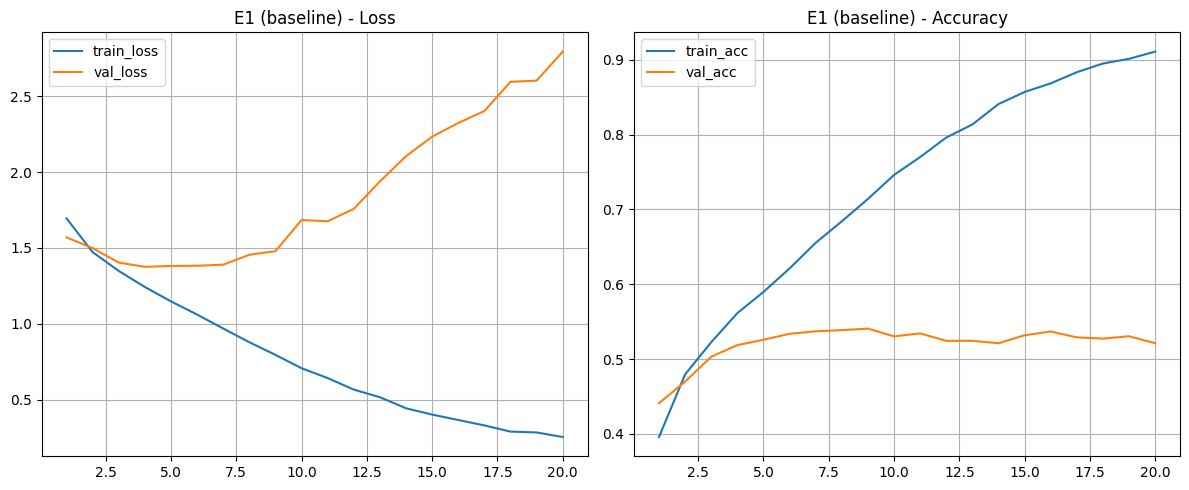

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: E1_curves.png
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/E1_curves.png
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/E1_curves.png


<Figure size 640x480 with 0 Axes>

In [28]:
plot_history(hist_E1,  title="E1 (baseline)", filename="E1_curves.png", use_drive=True)

## Эксперимент 2 ##

In [29]:
set_seed(SEED)
E2_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.3,
    "use_batchnorm": False
}

E2_model, hist_E2, _ = run_experiment(
    "E2",
    E2_cfg,
    opt_cfg_E,
    epochs = 20
)

epoch 01/20 | train loss = 1.7969, acc = 0.3571 | val loss = 1.6178, acc = 0.4224
epoch 02/20 | train loss = 1.6326, acc = 0.4222 | val loss = 1.5684, acc = 0.4480
epoch 03/20 | train loss = 1.5416, acc = 0.4552 | val loss = 1.4690, acc = 0.4876
epoch 04/20 | train loss = 1.4886, acc = 0.4755 | val loss = 1.4427, acc = 0.4923
epoch 05/20 | train loss = 1.4412, acc = 0.4903 | val loss = 1.4228, acc = 0.5037
epoch 06/20 | train loss = 1.4004, acc = 0.5060 | val loss = 1.4170, acc = 0.5102
epoch 07/20 | train loss = 1.3600, acc = 0.5195 | val loss = 1.3872, acc = 0.5155
epoch 08/20 | train loss = 1.3296, acc = 0.5301 | val loss = 1.3700, acc = 0.5242
epoch 09/20 | train loss = 1.2900, acc = 0.5413 | val loss = 1.3661, acc = 0.5276
epoch 10/20 | train loss = 1.2603, acc = 0.5522 | val loss = 1.3745, acc = 0.5234
epoch 11/20 | train loss = 1.2452, acc = 0.5609 | val loss = 1.3404, acc = 0.5331
epoch 12/20 | train loss = 1.2048, acc = 0.5681 | val loss = 1.3444, acc = 0.5368
epoch 13/20 | tr

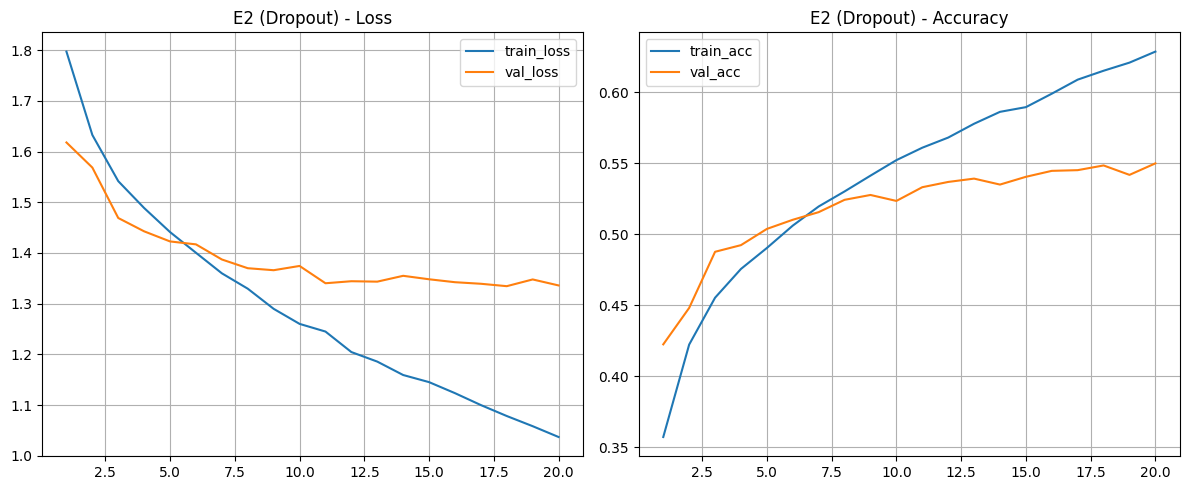

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: E2_curves.png
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/E2_curves.png
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/E2_curves.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plot_history(hist_E2,  title="E2 (Dropout)", filename="E2_curves.png", use_drive=True)

## Эксперимент 3 ##

In [48]:
set_seed(SEED)
E3_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": True
}

E3_model, hist_E3, _ = run_experiment(
    "E3",
    E3_cfg,
    opt_cfg_E,
    epochs = 20
)


epoch 01/20 | train loss = 1.6196, acc = 0.4177 | val loss = 1.4875, acc = 0.4727
epoch 02/20 | train loss = 1.3968, acc = 0.5007 | val loss = 1.4413, acc = 0.4905
epoch 03/20 | train loss = 1.2698, acc = 0.5468 | val loss = 1.3593, acc = 0.5149
epoch 04/20 | train loss = 1.1661, acc = 0.5835 | val loss = 1.3338, acc = 0.5240
epoch 05/20 | train loss = 1.0792, acc = 0.6137 | val loss = 1.3188, acc = 0.5413
epoch 06/20 | train loss = 0.9986, acc = 0.6431 | val loss = 1.3443, acc = 0.5340
epoch 07/20 | train loss = 0.9045, acc = 0.6788 | val loss = 1.3494, acc = 0.5460
epoch 08/20 | train loss = 0.8254, acc = 0.7065 | val loss = 1.3721, acc = 0.5459
epoch 09/20 | train loss = 0.7410, acc = 0.7378 | val loss = 1.3952, acc = 0.5482
epoch 10/20 | train loss = 0.6589, acc = 0.7675 | val loss = 1.4700, acc = 0.5420
epoch 11/20 | train loss = 0.5762, acc = 0.7979 | val loss = 1.5236, acc = 0.5527
epoch 12/20 | train loss = 0.4927, acc = 0.8278 | val loss = 1.6401, acc = 0.5431
epoch 13/20 | tr

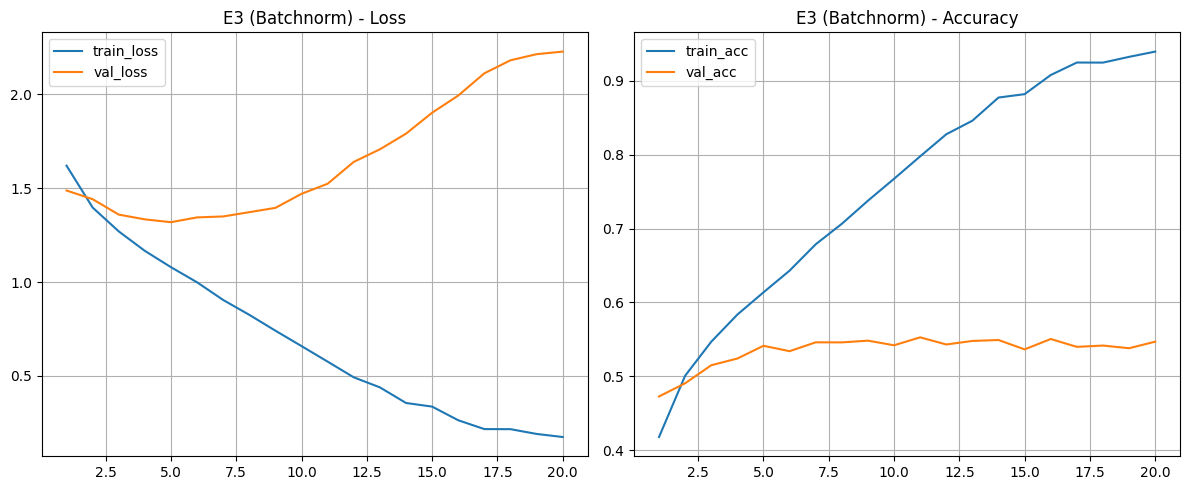

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: E3 _curves.png
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/E3 _curves.png
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/E3 _curves.png


<Figure size 640x480 with 0 Axes>

In [49]:
plot_history(hist_E3,  title="E3 (Batchnorm)", filename="E3 _curves.png", use_drive=True)

## Эксперимент 4 (E4) ##

In [30]:
set_seed(SEED)
E4_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": True
}
es = EarlyStopping(patience=5, min_delta=5e-5)

E4_model, hist_E4, config_e4 = run_experiment(
    "E4",
    E4_cfg,
    opt_cfg_E,
    epochs = 50,
    early_stopping=es
)


epoch 01/50 | train loss = 1.6196, acc = 0.4177 | val loss = 1.4875, acc = 0.4727
epoch 02/50 | train loss = 1.3968, acc = 0.5007 | val loss = 1.4413, acc = 0.4905
epoch 03/50 | train loss = 1.2698, acc = 0.5468 | val loss = 1.3593, acc = 0.5149
epoch 04/50 | train loss = 1.1661, acc = 0.5835 | val loss = 1.3338, acc = 0.5240
epoch 05/50 | train loss = 1.0792, acc = 0.6137 | val loss = 1.3188, acc = 0.5413
epoch 06/50 | train loss = 0.9986, acc = 0.6431 | val loss = 1.3443, acc = 0.5340
epoch 07/50 | train loss = 0.9045, acc = 0.6788 | val loss = 1.3494, acc = 0.5460
epoch 08/50 | train loss = 0.8254, acc = 0.7065 | val loss = 1.3721, acc = 0.5459
epoch 09/50 | train loss = 0.7410, acc = 0.7378 | val loss = 1.3952, acc = 0.5482
epoch 10/50 | train loss = 0.6589, acc = 0.7675 | val loss = 1.4700, acc = 0.5420
epoch 11/50 | train loss = 0.5762, acc = 0.7979 | val loss = 1.5236, acc = 0.5527
epoch 12/50 | train loss = 0.4927, acc = 0.8278 | val loss = 1.6401, acc = 0.5431
epoch 13/50 | tr

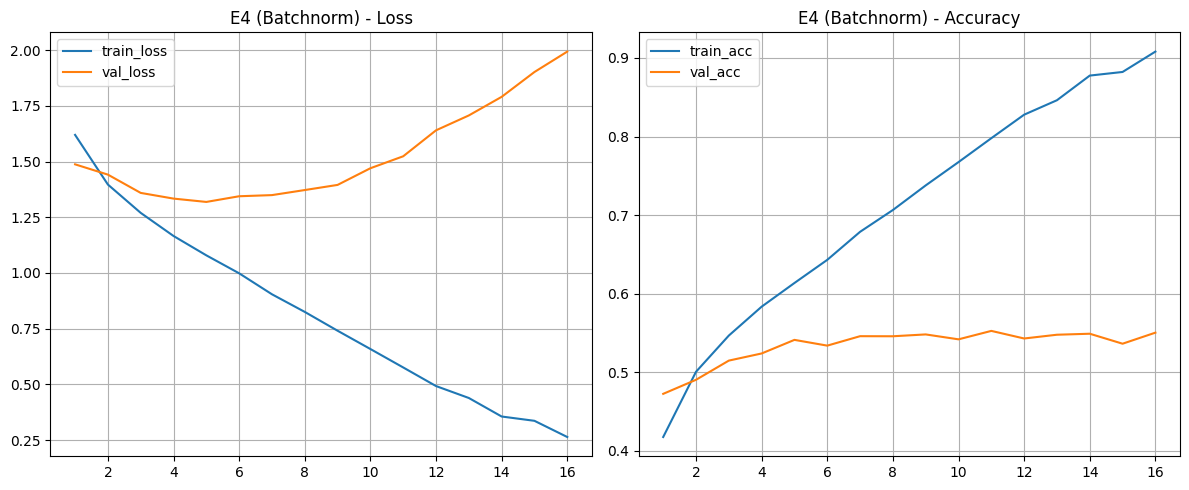

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: curves_best.png
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/curves_best.png
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/curves_best.png
Dropout Model test: loss=1.5646, acc=0.5377


<Figure size 640x480 with 0 Axes>

In [34]:
plot_history(hist_E4,  title="E4 (Batchnorm)", filename="curves_best.png", use_drive=True)
test_loss_E4, test_acc_E4 = evaluate(E4_model, test_loader, criterion, device)
print(f"Dropout Model test: loss={test_loss_E4:.4f}, acc={test_acc_E4:.4f}")

In [51]:
import shutil
# Сохранение лучшей модели (E4)
torch.save(E4_model.state_dict(), "best_model.pt")
drive_path = Path("/content/drive/MyDrive/Colab_Projects/HW08-09/best_model.pt")
drive_path.parent.mkdir(exist_ok=True)
shutil.copy("best_model.pt", drive_path)

print(f"Модель сохранена на Диск: {drive_path}")
print("Saved best_model.pt")

Модель сохранена на Диск: /content/drive/MyDrive/Colab_Projects/HW08-09/best_model.pt
Saved best_model.pt


In [38]:
config_json = json.dumps(config_e4, indent=2, ensure_ascii=False)
save_and_sync(Path("best_config.json"), content=config_json, use_drive=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: best_config.json
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/best_config.json
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/best_config.json


# HW 9 #

## O1 ##

In [39]:
set_seed(SEED)
opt_cfg_O1 = {
    "type": "Adam",
    "lr": 1e-1,
    "weight_decay": 0
}

O_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": False
}

O1_model, hist_O1, config_O1 = run_experiment(
    "O1",
    O_cfg,
    opt_cfg_O1,
    epochs = 8,
)

epoch 01/8 | train loss = 1497.3189, acc = 0.0997 | val loss = 2.3084, acc = 0.0970
epoch 02/8 | train loss = 2.4290, acc = 0.0997 | val loss = 2.3123, acc = 0.1016
epoch 03/8 | train loss = 2.3068, acc = 0.1011 | val loss = 2.3054, acc = 0.0970
epoch 04/8 | train loss = 2.3072, acc = 0.0992 | val loss = 2.3048, acc = 0.0975
epoch 05/8 | train loss = 2.3074, acc = 0.1005 | val loss = 2.3149, acc = 0.0959
epoch 06/8 | train loss = 2.3085, acc = 0.1007 | val loss = 2.3076, acc = 0.0970
epoch 07/8 | train loss = 2.3067, acc = 0.1002 | val loss = 2.3130, acc = 0.0979
epoch 08/8 | train loss = 2.3076, acc = 0.0992 | val loss = 2.3053, acc = 0.0959
Experiment O1 finished.
Epochs: 8
Best Val Acc: 0.1016


## O2 ##

In [40]:
opt_cfg_O2 = {
    "type": "Adam",
    "lr": 1e-5,
    "weight_decay": 0
}

O2_model, hist_O2, _ = run_experiment(
    "O2",
    O_cfg,
    opt_cfg_O2,
    epochs=8
)

epoch 01/8 | train loss = 2.1633, acc = 0.2575 | val loss = 2.0043, acc = 0.3089
epoch 02/8 | train loss = 1.8964, acc = 0.3382 | val loss = 1.8118, acc = 0.3662
epoch 03/8 | train loss = 1.7638, acc = 0.3816 | val loss = 1.7250, acc = 0.3948
epoch 04/8 | train loss = 1.6902, acc = 0.4077 | val loss = 1.6707, acc = 0.4105
epoch 05/8 | train loss = 1.6390, acc = 0.4257 | val loss = 1.6328, acc = 0.4255
epoch 06/8 | train loss = 1.6010, acc = 0.4400 | val loss = 1.6046, acc = 0.4302
epoch 07/8 | train loss = 1.5687, acc = 0.4507 | val loss = 1.5804, acc = 0.4452
epoch 08/8 | train loss = 1.5416, acc = 0.4615 | val loss = 1.5606, acc = 0.4532
Experiment O2 finished.
Epochs: 8
Best Val Acc: 0.4532


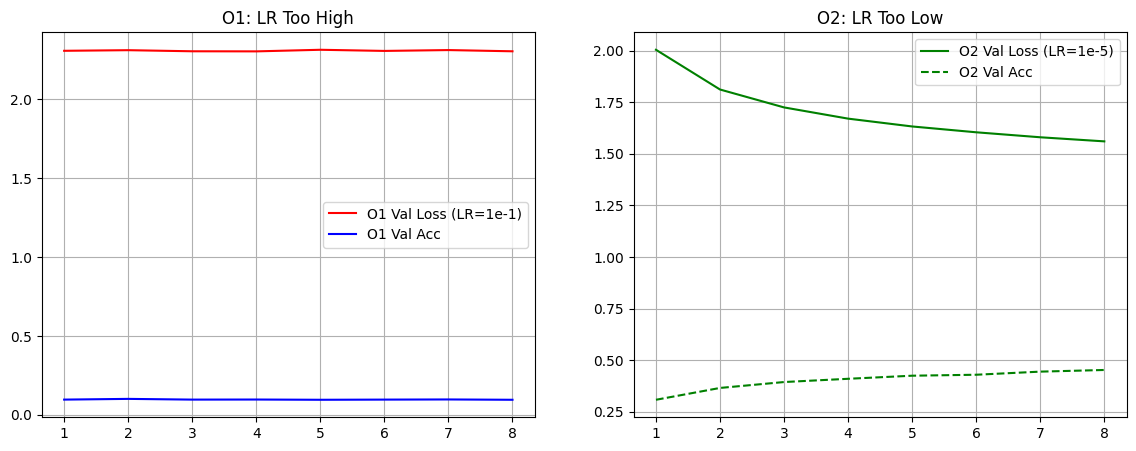

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: curves_lr_extemes
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/curves_lr_extemes
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/curves_lr_extemes


<Figure size 640x480 with 0 Axes>

In [42]:
# График сравнения LR (O1 и O2)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# O1 Plot
epochs_o1 = np.arange(1, len(hist_O1["train_loss"]) + 1)
axs[0].plot(epochs_o1, hist_O1["val_loss"], label="O1 Val Loss (LR=1e-1)", color="red")
axs[0].plot(epochs_o1, hist_O1["val_acc"], label="O1 Val Acc", color="blue")
axs[0].set_title("O1: LR Too High")
axs[0].legend()
axs[0].grid(True)

# O2 Plot
epochs_o2 = np.arange(1, len(hist_O2["train_loss"]) + 1)
axs[1].plot(epochs_o2, hist_O2["val_loss"], label="O2 Val Loss (LR=1e-5)", color="green")
axs[1].plot(epochs_o2, hist_O2["val_acc"], label="O2 Val Acc", linestyle="--", color="green")
axs[1].set_title("O2: LR Too Low")
axs[1].legend()
axs[1].grid(True)


plt.show()
plt.tight_layout()
buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
image_bytes = buf.getvalue()
plt.close(fig)  # Освобождаем память
   
    
    # --- Сохраняем файл через нашу функцию ---
save_and_sync(Path("curves_lr_extemes"), content=image_bytes, use_drive=True)


## O3 ##

In [43]:
opt_cfg_O3 = {
    "type": "SGD",
    "lr": 1e-3,
    "momentum": 0.9,
    "weight_decay": 1e-4
}

O3_model, hist_O3, _ = run_experiment(
    "O3",
    O_cfg,
    opt_cfg_O3,
    epochs = 15
)

epoch 01/15 | train loss = 2.2744, acc = 0.1848 | val loss = 2.2323, acc = 0.2571
epoch 02/15 | train loss = 2.1649, acc = 0.2631 | val loss = 2.0925, acc = 0.2784
epoch 03/15 | train loss = 2.0279, acc = 0.2848 | val loss = 1.9698, acc = 0.3037
epoch 04/15 | train loss = 1.9231, acc = 0.3173 | val loss = 1.8801, acc = 0.3343
epoch 05/15 | train loss = 1.8453, acc = 0.3452 | val loss = 1.8141, acc = 0.3621
epoch 06/15 | train loss = 1.7847, acc = 0.3690 | val loss = 1.7601, acc = 0.3792
epoch 07/15 | train loss = 1.7323, acc = 0.3884 | val loss = 1.7143, acc = 0.3929
epoch 08/15 | train loss = 1.6881, acc = 0.4033 | val loss = 1.6771, acc = 0.4046
epoch 09/15 | train loss = 1.6497, acc = 0.4187 | val loss = 1.6447, acc = 0.4151
epoch 10/15 | train loss = 1.6162, acc = 0.4294 | val loss = 1.6184, acc = 0.4266
epoch 11/15 | train loss = 1.5845, acc = 0.4399 | val loss = 1.5943, acc = 0.4358
epoch 12/15 | train loss = 1.5567, acc = 0.4516 | val loss = 1.5699, acc = 0.4448
epoch 13/15 | tr

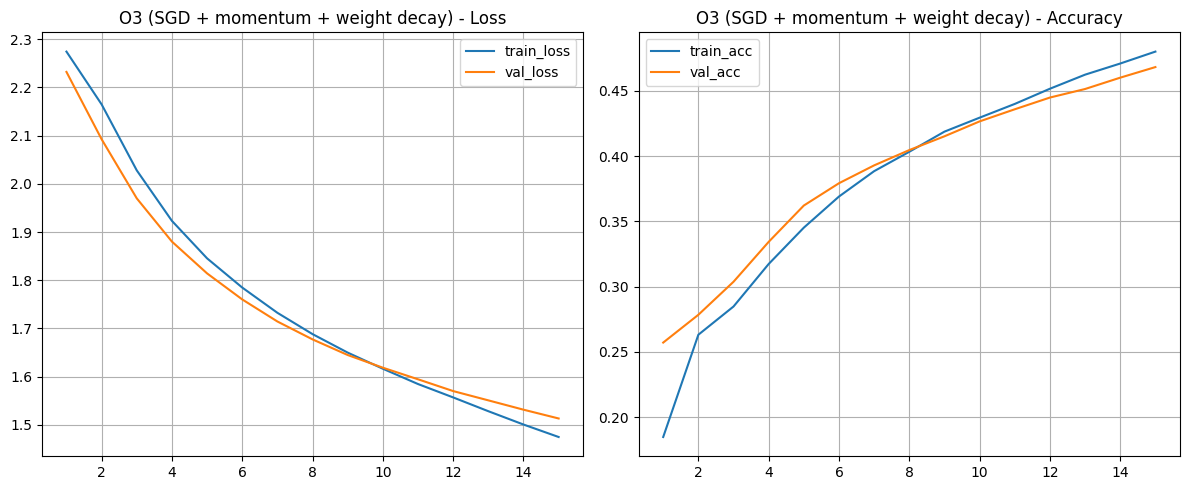

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: O3_curves.png
Копия на Google Диске: /content/drive/MyDrive/Colab_Projects/HW08-09/O3_curves.png
Локально появится в: ~/Google Drive/Colab_Projects/HW08-09/O3_curves.png


<Figure size 640x480 with 0 Axes>

In [44]:
plot_history(hist_O3,  title="O3 (SGD + momentum + weight decay)", filename="O3_curves.png", use_drive=True)

## Результаты ##

In [52]:
import csv
from pathlib import Path
from google.colab import drive

def save_runs_to_drive(all_runs, folder_name="MyProject"):
    """
    Сохраняет runs.csv в Google Drive для локальной синхронизации
    """
    # Монтируем диск (только один раз за сессию)
    drive.mount('/content/drive', force_remount=False)
    
    # Путь на Диске
    drive_path = Path(f"/content/drive/MyDrive/{folder_name}")
    drive_path.mkdir(exist_ok=True)
    
    csv_path = drive_path / "runs.csv"
    
    if all_runs:
        keys = all_runs[0].keys()
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(all_runs)
        
        print(f"Файл сохранён: {csv_path}")
        print(f"Локальный путь: ~/Google Drive/{folder_name}/runs.csv")
        return csv_path
    else:
        print("Нет данных для сохранения")
        return None

# Использование
save_runs_to_drive(all_runs, folder_name="Colab_Projects/HW08-09")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл сохранён: /content/drive/MyDrive/Colab_Projects/HW08-09/runs.csv
Локальный путь: ~/Google Drive/Colab_Projects/HW08-09/runs.csv


PosixPath('/content/drive/MyDrive/Colab_Projects/HW08-09/runs.csv')